In [2]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

from dataset import DATA_TRANSFORM
from models import VanillaVae

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [7]:
image_path = "/data/Vae/Dataset/MNIST_data/test/1_98.png"
model_weight_path = "/data/Vae/Weight/vae_epoch_dim20_30.pth"

image = Image.open(image_path)
image_transform = DATA_TRANSFORM["val"]
image_tensor = image_transform(image).unsqueeze(0).to(device)

vae = VanillaVae(in_channels=1, latent_dim=20).to(device)
vae.load_state_dict(torch.load(model_weight_path, weights_only=True))
mu, log_var = vae.encode(image_tensor)
print(mu[0, :10], torch.exp(log_var[0, :10]))
image_latent = vae.re_parameterize(mu, log_var)



tensor([-0.3941,  1.6061,  0.9947,  0.0629, -0.6618,  0.5557, -2.0723, -0.0626,
         0.8380, -1.1917], device='cuda:0', grad_fn=<SliceBackward0>) tensor([0.0294, 0.0215, 0.0174, 0.0138, 0.0593, 0.0200, 0.0300, 0.2254, 0.0286,
        0.0118], device='cuda:0', grad_fn=<ExpBackward0>)


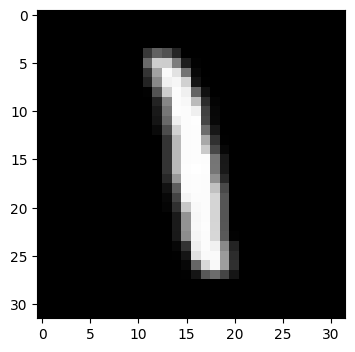

In [5]:
image_data = image_tensor.squeeze(0).cpu().detach().numpy().reshape(32, 32)
plt.figure(figsize=(4, 4))
plt.imshow(image_data, cmap='gray')

tensor([[-0.6190, -0.5464, -0.7810, -0.9291, -0.3335, -0.3912, -0.2123, -0.0159,
          0.6627,  0.9259, -0.5391, -0.6012, -0.8507,  0.6698, -0.8163, -0.8110,
         -0.7799,  1.3500, -0.1643, -0.0211]], device='cuda:0')


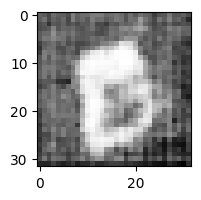

In [50]:
# 随机采样 生成图
image_latent = torch.randn((1, 20)).to(device)
print(image_latent)
image_tensor = vae.decode(image_latent)
image_data = image_tensor.squeeze(0).cpu().detach().numpy().reshape(32, 32)
plt.figure(figsize=(2, 2))
plt.imshow(image_data, cmap='gray')
